---
title: Lower-Order Associations
date: 09/2025
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
  - name: Fernando Pérez
    affiliation: ucb
  - name: Jon McAuliffe
    affiliation: ucb
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

A notebook showcasing visualizations and summary statistics on how AR characteristics vary with their landfalling impacts. We showcase univariate associations as well as associations with bivariate combinations of characteristics to uncover first-order interactions.

In [1]:
import xarray as xr
import pandas as pd
import os
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, binned_statistic_2d
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams['text.usetex'] = True

from artools.display_utils import display_catalog

/scratch/users/butlerj/conda/envs/extreme_antarctic_ars_python/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
catalog = pd.read_hdf('../outputs/data_products/full_dataset_clean.h5')
subcat = catalog[['data_array', 'start_date', 
                  'end_date', 'max_IWV_ais', 
                  'max_ocean_SLP_gradient', 'region', 
                  'duration', 'max_south_extent', 
                  'cumulative_landfalling_area', 'avg_landfalling_minomega', 
                  'max_landfalling_v850hPa', 'max_T2M_anomaly_ais', 
                  'cumulative_rainfall_ais', 'cumulative_snowfall_ais']]

In [3]:
catalog.shape

(3082, 19)

## Univariate Associations

We first explore associations between individual AR characteristic summaries and the landfalling cumulative snowfall and 2m-temperature anomaly. Below, we plot the bivariate KDE for different combinations of AR outcomes and covariates. The plotted correlations $\rho$ is Spearman's rank correlation coefficient, which measures the degree to which two variables exhibit a monotonic relationship. So, it is a more general notion of correlation than Pearson's, which measures the degree to which two variables exhibit a linear relationship.

We first define a function to plot a pair of plots, with each one showing the relationship between one of our two impacts of interest and a particular characteristic.

In [4]:
feature_config = {
    'max_landfalling_v850hPa': {'label': 'V850 hPa (m/s)', 'xlim': (10,50)},
    'max_IWV_ais': {'label': 'IWV (kg/m$^{2}$)', 'xlim': (0,25)},
    'cumulative_landfalling_area': {'label': 'CLA (km$^{2}$ day)', 'xlim': (-0.5*(10**6), 3*(10**6))},
    'max_south_extent': {'label': 'South Extent ($^{\\circ}$ Lat.)', 'xlim': None},
    'max_ocean_SLP_gradient': {'label': 'SLP Gradient (Pa/km)', 'xlim': (0,12)},
    'avg_landfalling_minomega': {'label': 'Min. Omega (Pa/s)', 'xlim': (-1.5,0)}
}

def plot_impact_pair_on_axes(x_col, ax1, ax2, catalog, impact1='max_T2M_anomaly_ais', impact2='cumulative_snowfall_ais'):
    '''
    Plots KDE plots for a given characteristic against two impacts on provided axes.
    '''
    # fetch formatting from dictionary, fallback to column name if not found
    config = feature_config.get(x_col, {'label': x_col, 'xlim': None})
    x_label = config['label']
    x_limit = config['xlim']

    # plot relationship with temperature anomaly
    corr1 = round(spearmanr(catalog[x_col], catalog[impact1]).statistic, 2)
    sns.kdeplot(data=catalog, x=x_col, y=impact1, cmap='OrRd', fill=True, ax=ax1)
    
    ax1.set_xlabel(x_label, fontsize=14)
    ax1.set_ylabel('T Anomaly ($^{\\circ}$C)', fontsize=14)
    if x_limit:
        ax1.set_xlim(x_limit)
    ax1.annotate(text='$\\rho$ = '+ str(corr1), xy=(0.6, 0.85), xycoords='axes fraction', fontsize=17)

    # plot relationship with snowfall
    corr2 = round(spearmanr(catalog[x_col], catalog[impact2]).statistic, 2)
    sns.kdeplot(data=catalog, x=x_col, y=impact2, cmap='GnBu', fill=True, ax=ax2)
    
    ax2.set_xlabel(x_label, fontsize=14)
    ax2.set_ylabel('Snow (Gt)', fontsize=14)
    ax2.set_ylim(-0.2, 3) 
    if x_limit:
        ax2.set_xlim(x_limit)
    ax2.annotate(text='$\\rho$ = '+ str(corr2), xy=(0.6, 0.85), xycoords='axes fraction', fontsize=17)

Starting with the maximum integrated water vapor underneath the landfalling footprint of the AR. It seems like there is a positive correlation with snowfall, but not much of an association with 2m-temperature.

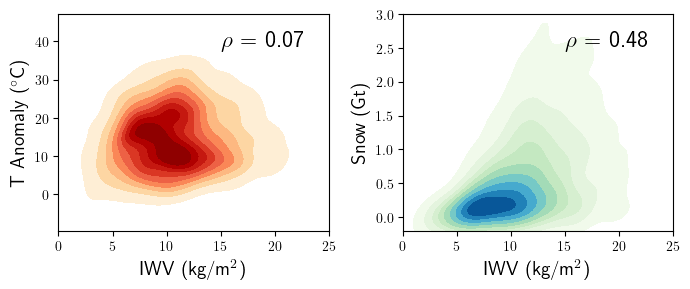

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

plot_impact_pair_on_axes('max_IWV_ais', ax1=axs[0], ax2=axs[1], catalog=subcat)

plt.tight_layout()
plt.show()

A slightly positive correlation between the maximum landfalling 850 hPa wind underneath the footprint of the storm and both outcomes!

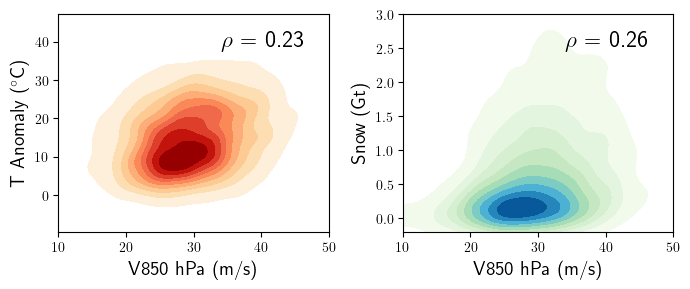

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

plot_impact_pair_on_axes('max_landfalling_v850hPa', ax1=axs[0], ax2=axs[1], catalog=subcat)

plt.tight_layout()
plt.show()

A *very* strong positive correlation between snowfall and storm cumulative landfalling area, and a somewhat weaker but still strong association between the maximum 2m-temperature anomaly and storm cumulative landfalling area. It's known that cumulative precipitation is both a product of precipitation intensity and how much time and space the storm spends in a particular location. Here, we see that CLA is very highly predictive of snowfall just on its own.

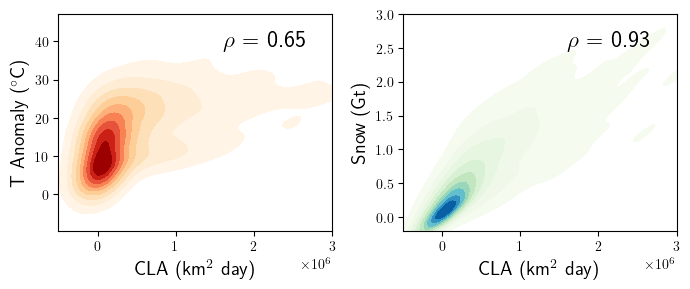

In [7]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

plot_impact_pair_on_axes('cumulative_landfalling_area', ax1=axs[0], ax2=axs[1], catalog=subcat)

plt.tight_layout()
plt.show()

A fairly moderate negative correlation between how far south the storm travels and the temperature anomalies and snowfall impacts. Storms that travel further south tend to have higher 2m-temperature anomalies and more cumulative snowfall impacts.

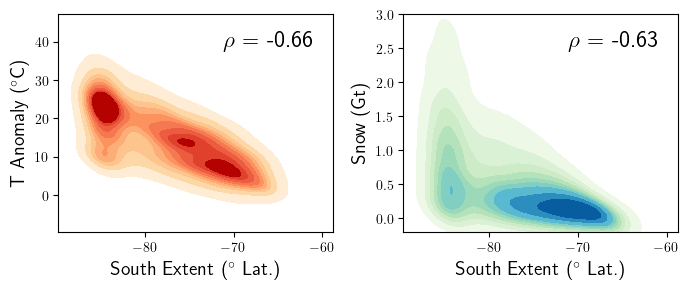

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

plot_impact_pair_on_axes('max_south_extent', ax1=axs[0], ax2=axs[1], catalog=subcat)

plt.tight_layout()
plt.show()

Not much of a correlation at all between the landfalling sea-level pressure gradients and the outcome variables.

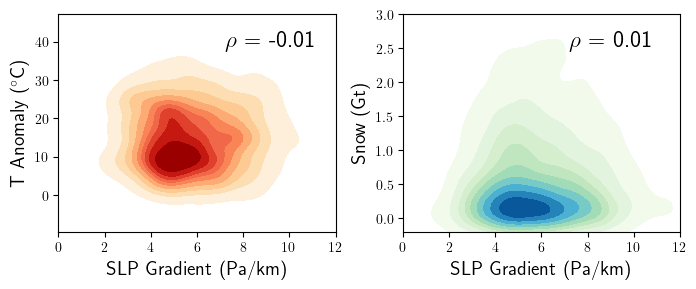

In [9]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

plot_impact_pair_on_axes('max_ocean_SLP_gradient', ax1=axs[0], ax2=axs[1], catalog=subcat)

plt.tight_layout()
plt.show()

A very slight negative correlation between the average landfalling minimum omega (minimum taken pixelwise across all available atmospheric levels).

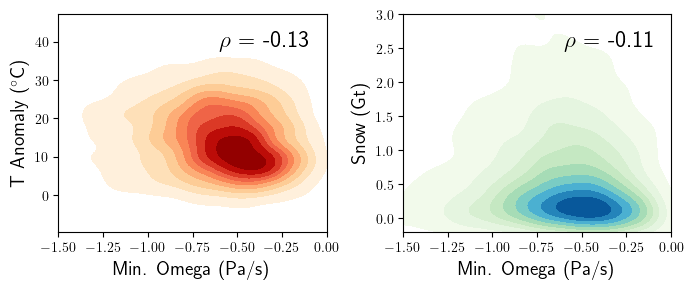

In [10]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

plot_impact_pair_on_axes('avg_landfalling_minomega', ax1=axs[0], ax2=axs[1], catalog=subcat)

plt.tight_layout()
plt.show()

Let's now collect all of our plots into one big plot for the full paper!

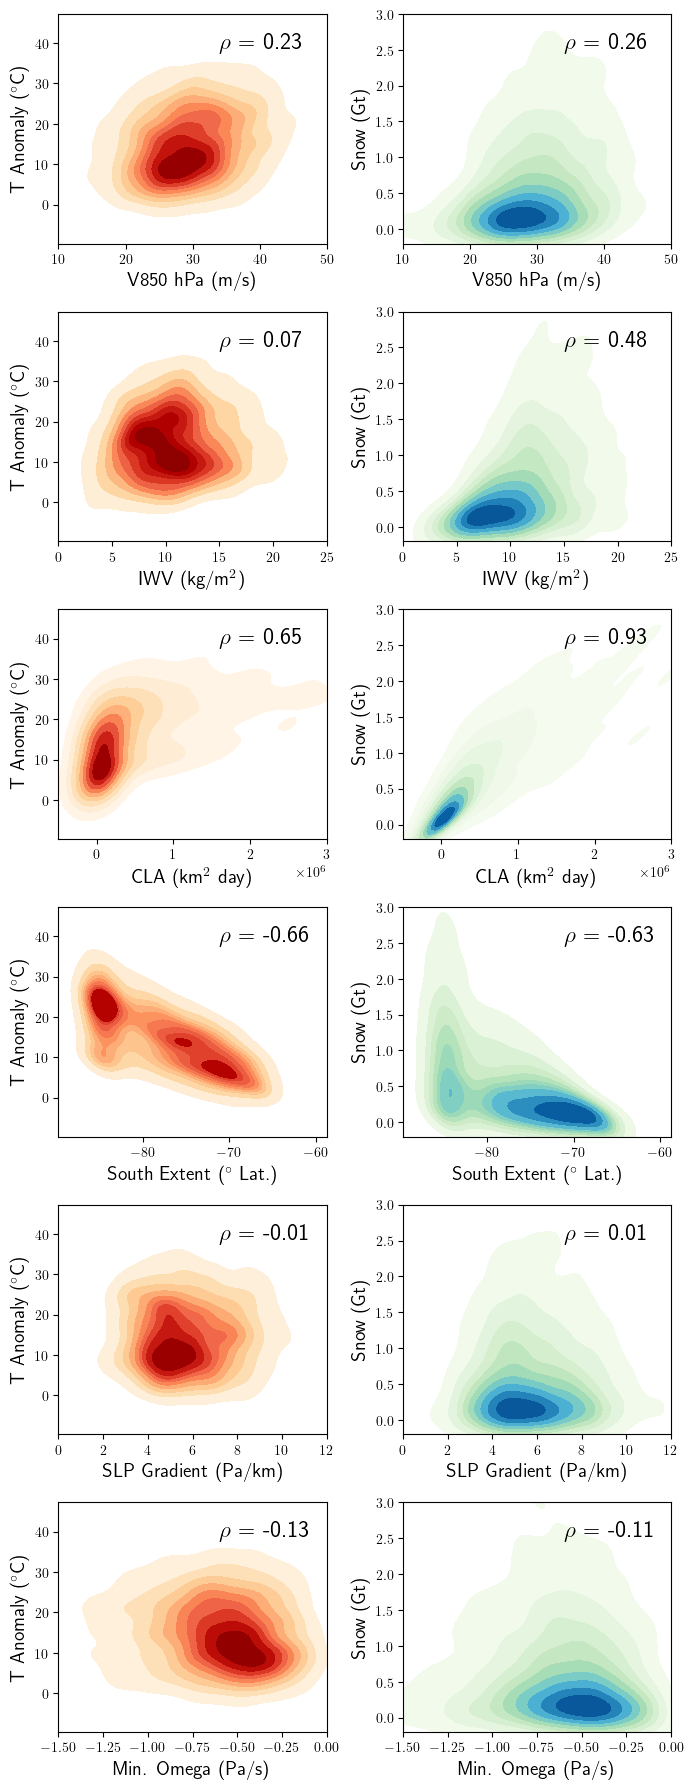

In [11]:
features = list(feature_config.keys())

fig, axs = plt.subplots(nrows=6, ncols=2, figsize=(7, 18))

for i, feature in enumerate(features):
    plot_impact_pair_on_axes(feature, ax1=axs[i, 0], ax2=axs[i, 1], catalog=subcat)

plt.tight_layout()
plt.savefig('../outputs/plots/univariate_associations_all.png', dpi=300)
plt.show()

## Bivariate Associations

Now, let's look at some associations between bivariate combinations of characteristics and our outcomes of interest. In the following plots, we bin the ARs into 2D bins based on combos of particular characteristics we specify. To get a sense of the impact for each bin, we color the bin based on the average impact of all ARs in that bin. As before, we define some plotting functions to make our lives easier. We'll summarize some noteworthy associations with each combination.

In [12]:
def add_joint_plot(ax, x, y, z, cmap, bins = 15, title='', xlabel='', ylabel='', vmin=None, vmax=None, show_cbar=True, tick_size=16, label_size=24):
    '''
    Create one such joint plot.
    '''
    divider = make_axes_locatable(ax)
    
    ax_top = divider.append_axes('top', size='20%', pad=0.1, sharex=ax)
    ax_right = divider.append_axes('right', size='20%', pad=0.1, sharey=ax)

    stat, x_edge, y_edge, _ = binned_statistic_2d(
            x, y, values=z, statistic='mean', bins=bins)
    mappable = ax.imshow(
        stat.T,
        origin='lower',
        extent=[x_edge[0], x_edge[-1], y_edge[0], y_edge[-1]],
        cmap=cmap,
        aspect='auto',
        vmin=vmin,
        vmax=vmax
    )
    sns.histplot(x=x, ax=ax_top, bins=bins, stat='count', color='gray', alpha=0.6, element='bars')
    sns.histplot(y=y, ax=ax_right, bins=bins, stat='count', color='gray', alpha=0.6, element='bars')

    ax_top.tick_params(axis='x', labelbottom=False)
    #ax_top.tick_params(axis='y', labelleft=False, left=False)
    ax_right.tick_params(axis='y', labelleft=False)
    #ax_right.tick_params(axis='x', labelbottom=False, bottom=False)
    ax_top.set_xlabel('')
    ax_top.set_ylabel('')
    ax_right.set_xlabel('')
    ax_right.set_ylabel('')

    if show_cbar:
        ax_cbar = divider.append_axes('top', size='5%', pad=0.3)
        plt.colorbar(mappable, cax=ax_cbar, orientation='horizontal')
        ax_cbar.tick_params(axis='x', labelsize=tick_size)

    ax.set_xlabel(xlabel, fontsize=label_size)
    ax.set_ylabel(ylabel, fontsize=label_size)

    ax.tick_params(axis='both', which='major', labelsize=tick_size, length=6, width=1.5)
    ax_top.tick_params(axis='y', labelsize=tick_size)
    ax_right.tick_params(axis='x', labelsize=tick_size)

    return mappable


In [13]:
def plot_feature_vs_others(target_col, z_col, catalog):
    '''
    Plots a target characteristic on the x-axis against the other 5 characteristics 
    on the y-axis, colored by the z_col (impact).
    '''
    # Filter out the target column to get the 5 remaining features
    all_features = list(feature_config.keys())
    other_features = [f for f in all_features if f != target_col]

    # Create a 1x5 grid with plenty of width to accommodate marginal axes and colorbars
    fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(28, 6))

    if z_col == 'max_T2M_anomaly_ais':
        suptitle = 'T Anomaly ($^{\\circ}$C)'
        cmap = 'YlOrRd'

    else:
        suptitle = 'Snow (Gt)'
        cmap = 'YlGnBu'

    fig.suptitle(suptitle, fontsize=40)

    # Fetch the x-axis label from our config dictionary
    x_label = feature_config.get(target_col, {"label": target_col})["label"]

    for i, other_col in enumerate(other_features):
        ax = axs[i]
        
        # Fetch the y-axis label for the current loop iteration
        y_label = feature_config.get(other_col, {"label": other_col})["label"]

        # Extract data
        x_data = catalog[target_col]
        y_data = catalog[other_col]
        z_data = catalog[z_col]

        # Determine a clean title (e.g., replacing underscores for readability)
        plot_title = f"Mean {z_col.replace('_', ' ').title()}"

        # Call your custom plotting function
        add_joint_plot(
            ax=ax,
            x=x_data,
            y=y_data,
            z=z_data,
            cmap=cmap,
            bins=15,
            title=plot_title,
            xlabel=x_label,
            ylabel=y_label
        )

    plt.tight_layout()
    plt.show()

Some potentially noteworthy findings:

+ Wind speed seems more important than IWV. It seems that storms with more moderate amounts of IWV can have higher 2m temperature anomalies if the windspeed is also higher.
+ Storms with higher CLA and lower IWV tend to have higher 2m-temperature anomalies
+ No matter IWV, it seems like storms that go farther south have higher 2m-temperature anomalies
+ No discernible patterns. Perhaps a slight preference for higher SLP gradients, regardless of IWV, but nothing too discernible
+ Higher omega seems to lead to higher 2m-temperature anomalies, across IWV. More average values of IWV can produce really high temperature anomalies if paired with high omega. At higher levels of omega, though, lower IWV seems to correspond to lower temperature anomalies. There does appear to be some interactions.

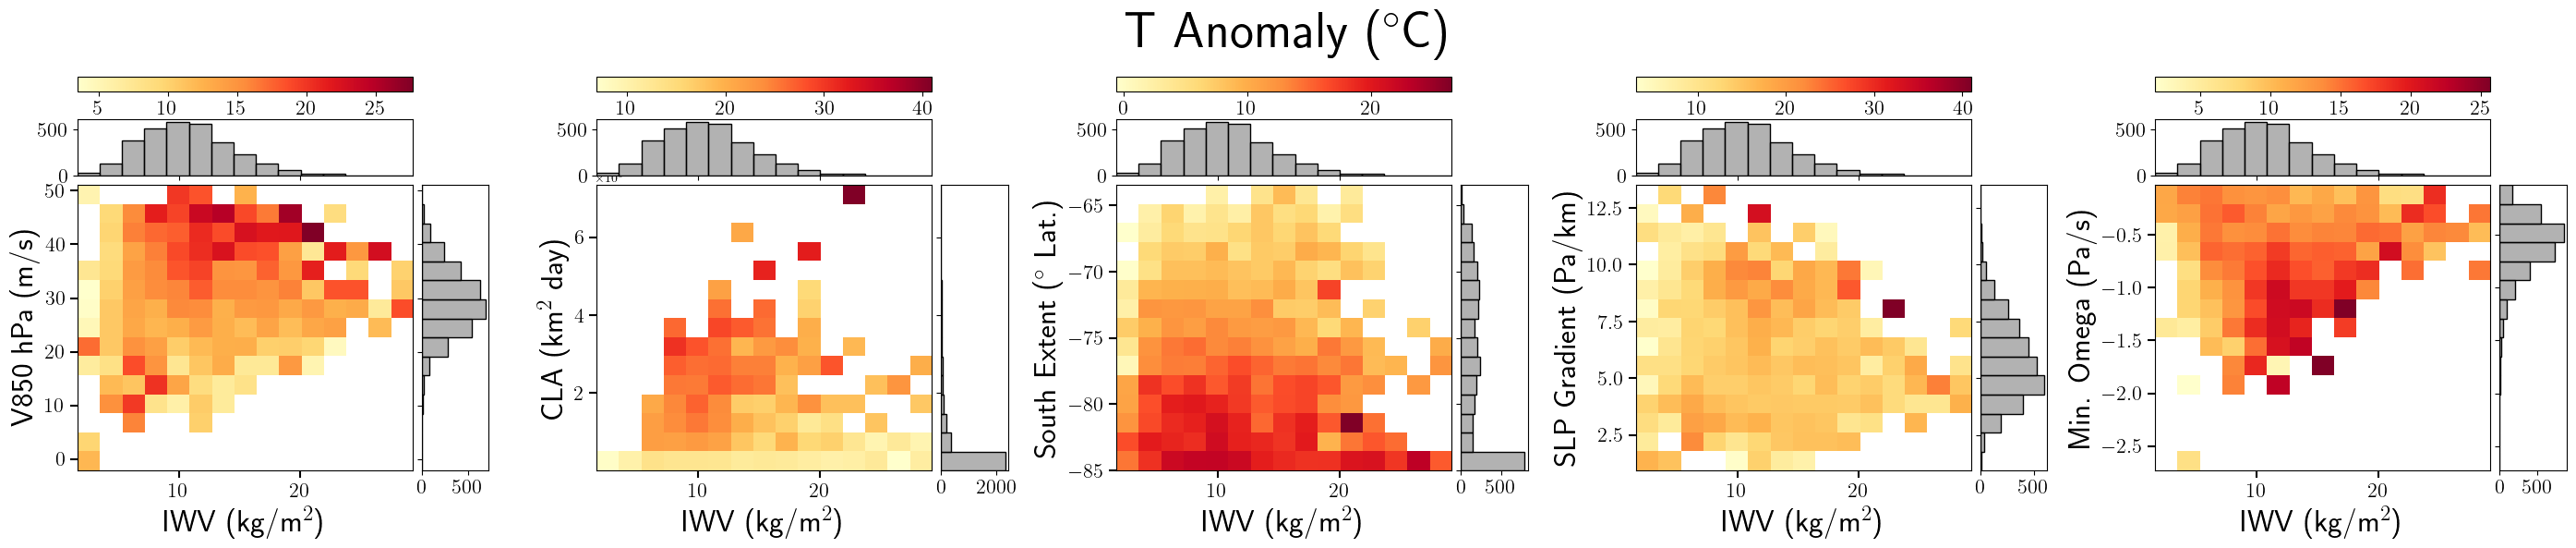

In [14]:
plot_feature_vs_others(
    target_col='max_IWV_ais', 
    z_col='max_T2M_anomaly_ais', 
    catalog=subcat)

Some noteworthy findings:
+ ARs with higher CLA and higher wind seem to have higher 2m-temperature anomalies, but the patterns aren't extremely discernible.
+ ARs with high wind and that travel further south have higher temperature anomalies
+ Rather difficult to discern a pattern. Seems like just high wind leads to higher 2m-temperatures, and strangely that some cases of higher wind but lower SLP gradients have higher 2m-temperature anomalies.
+ Not as discernible either. Of course higher wind leads to higher 2m-temperature anomalies, and seems also that higher omega leads to higher anomalies, but only if wind is also high.

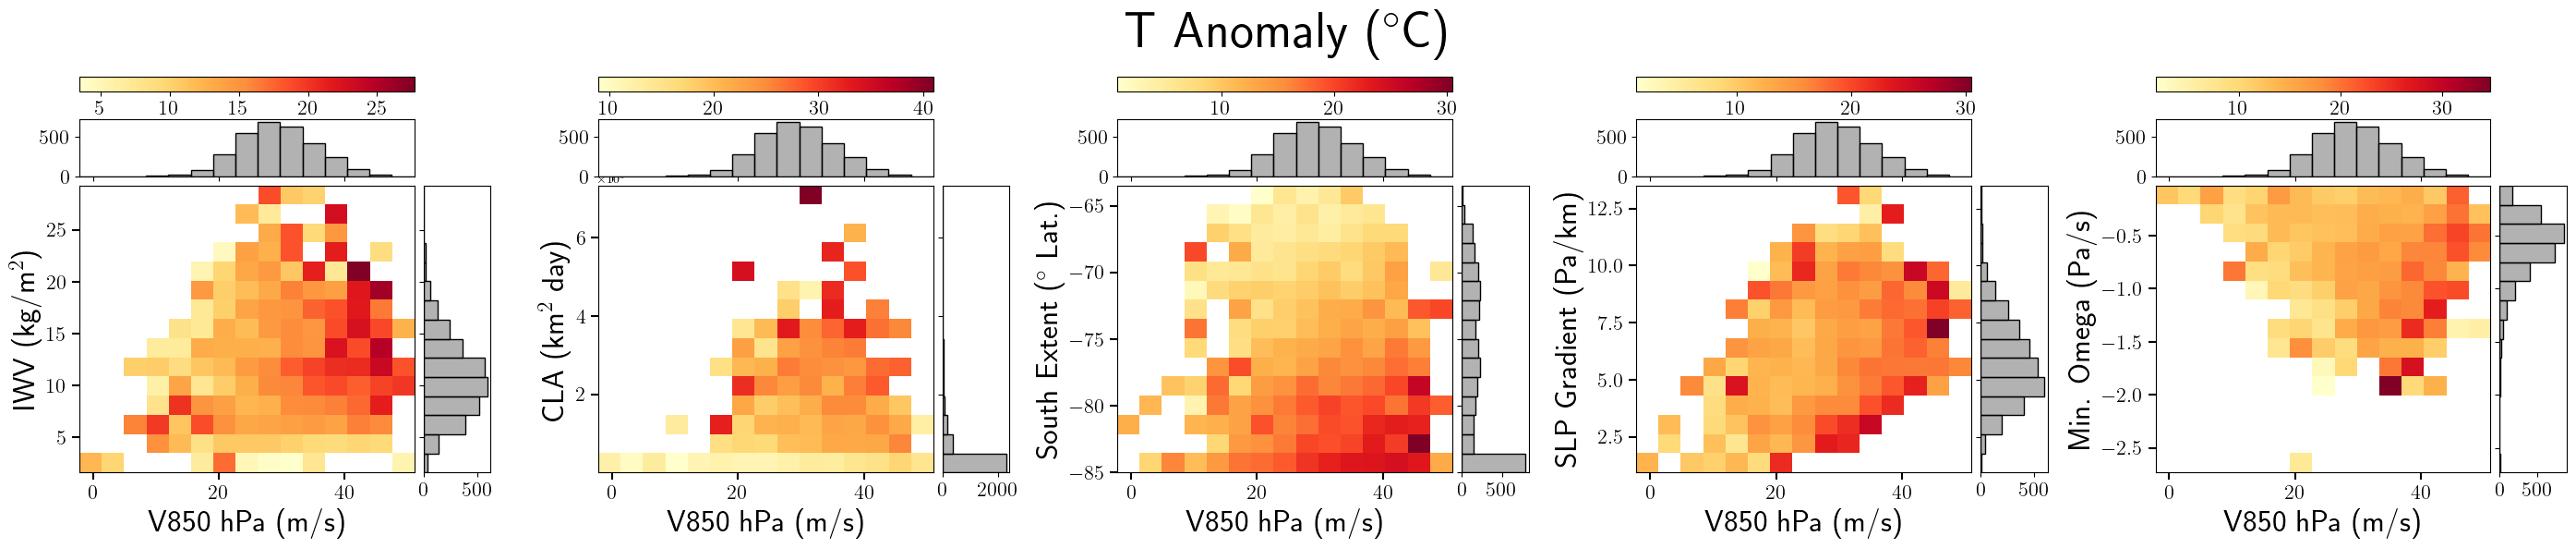

In [15]:
plot_feature_vs_others(
    target_col='max_landfalling_v850hPa', 
    z_col='max_T2M_anomaly_ais', 
    catalog=subcat)

Some noteworthy findings:
+ ARs that travel further south with fixed CLA and storms with fixed southern latitudes with greater CLA tend to have higher 2m-temperature anomalies. In fact, seems like you don't even need to go all the way to the pole: you can stop short and have a high CLA still.
+ No interesting interactions or patterns with SLP gradient and CLA.
+ Seems like storms with really high CLA can have high temperature anomalies even with small minimum omega values, but that for smaller CLA storms, higher minimum omega is associated with higher 2m temperature anomalies.

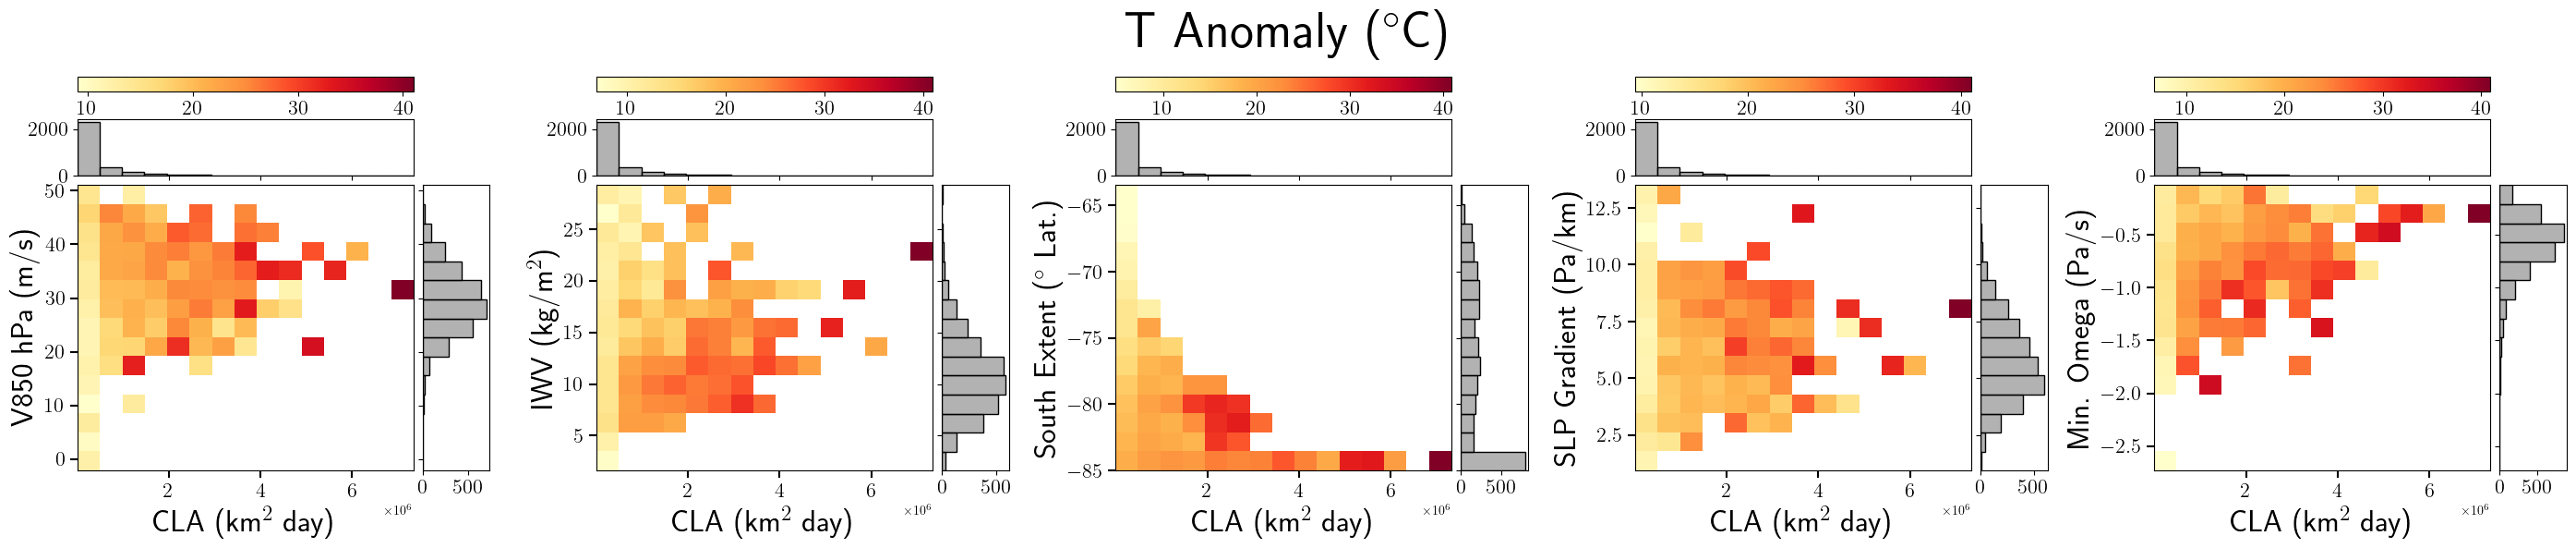

In [16]:
plot_feature_vs_others(
    target_col='cumulative_landfalling_area', 
    z_col='max_T2M_anomaly_ais', 
    catalog=subcat)

Some noteworthy findings:
+ The higher the SLP gradient and the farther south the AR travels, the higher the 2m temperature anomaly. However, it seems like it increases much faster with southern latitude as opposed to SLP gradient.
+ ARs with higher omega and travel further south have higher 2m-temperature anomalies.

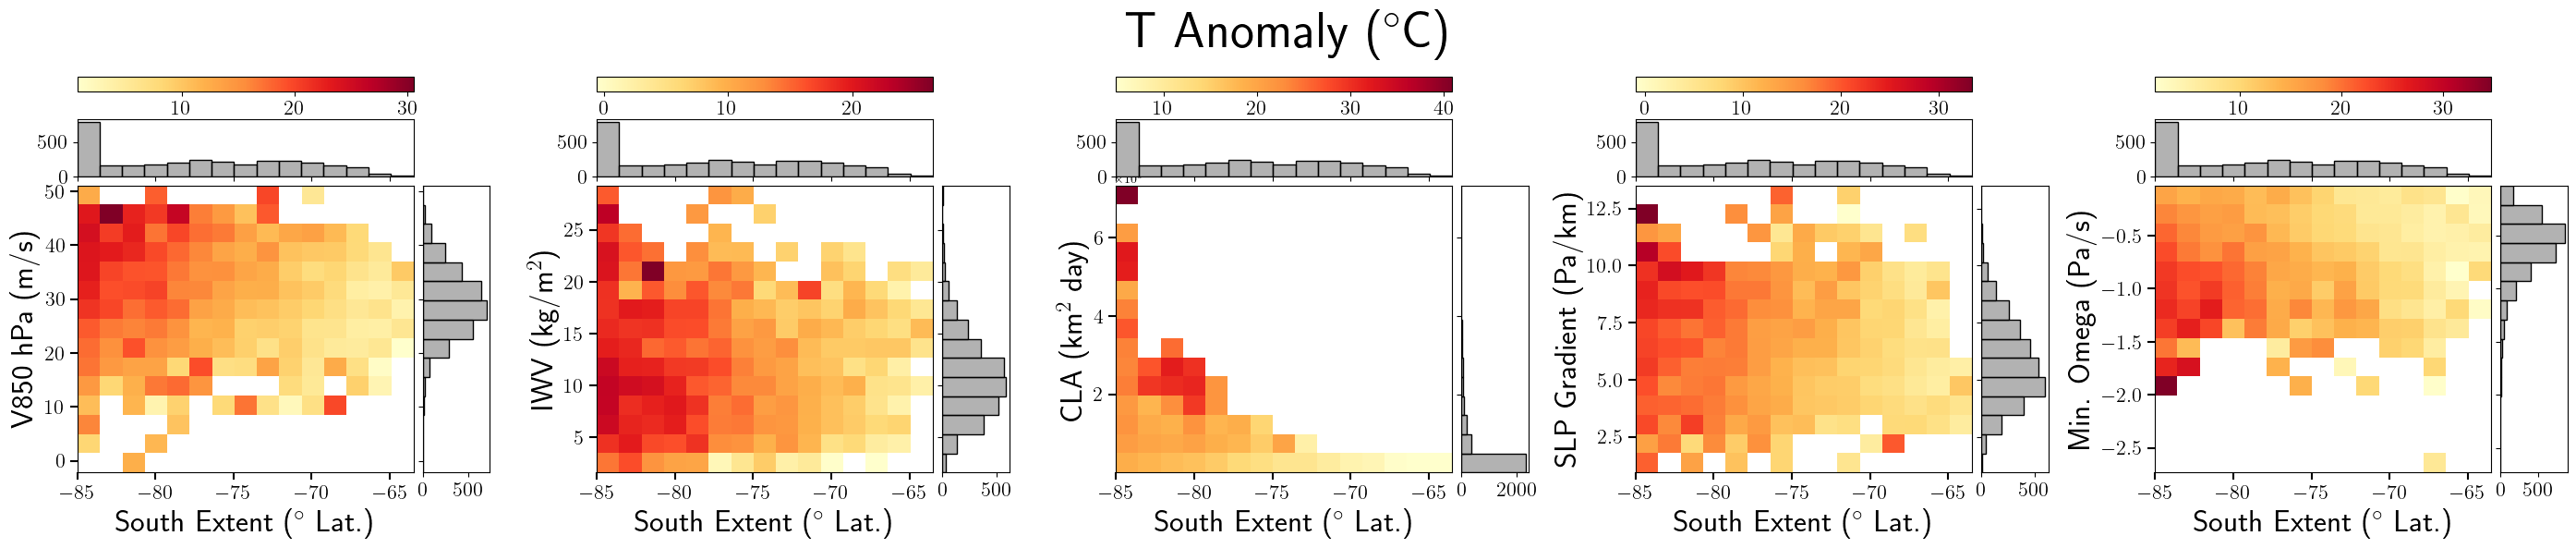

In [17]:
plot_feature_vs_others(
    target_col='max_south_extent', 
    z_col='max_T2M_anomaly_ais', 
    catalog=subcat)

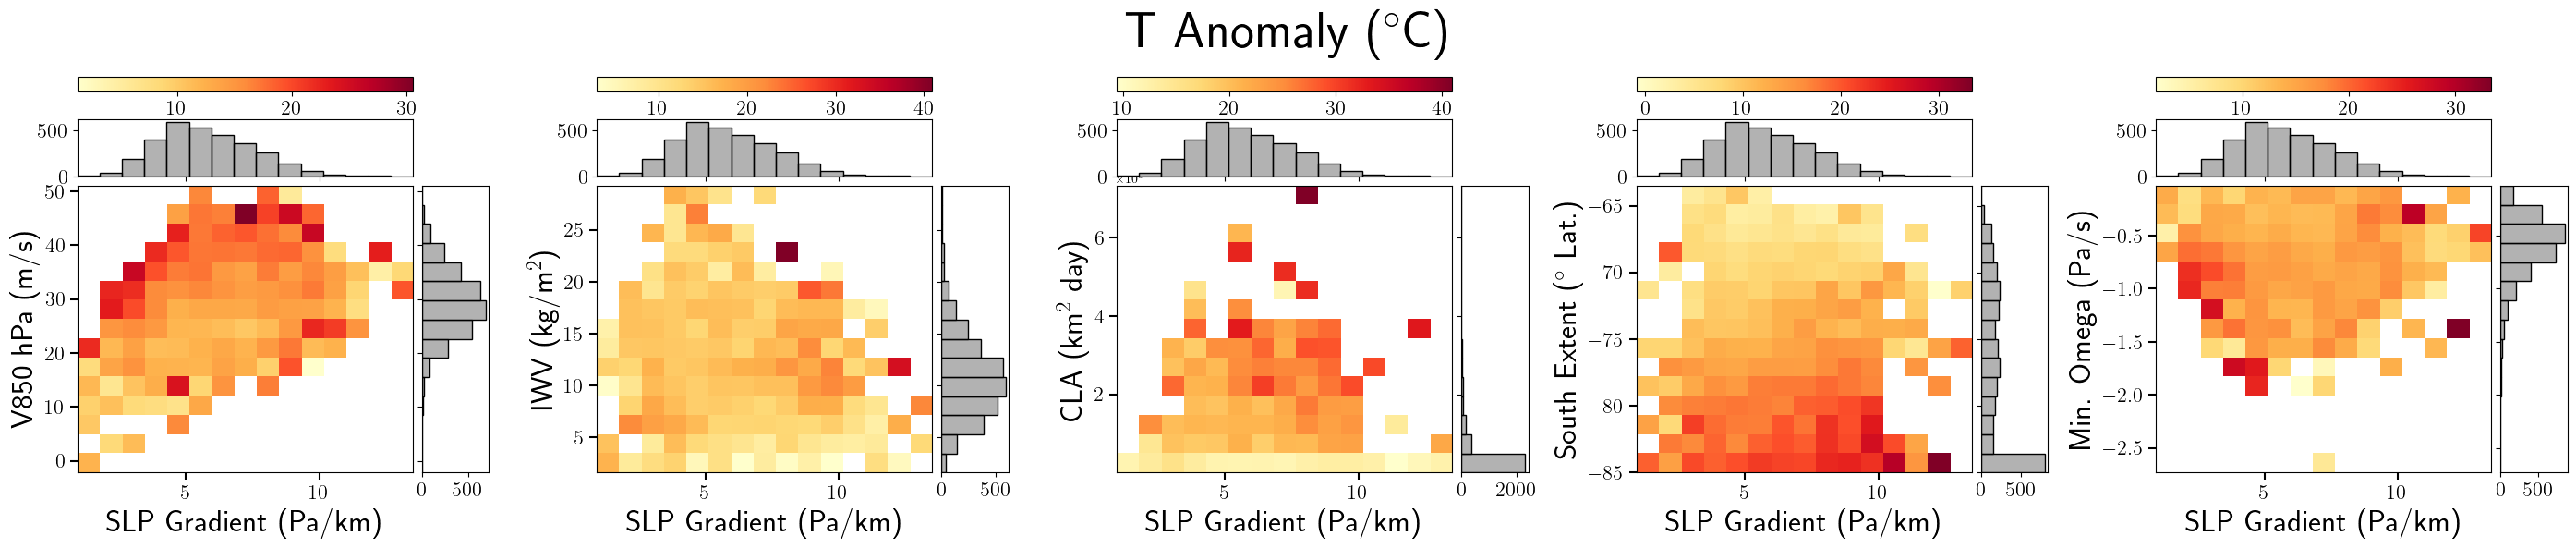

In [18]:
plot_feature_vs_others(
    target_col='max_ocean_SLP_gradient', 
    z_col='max_T2M_anomaly_ais', 
    catalog=subcat)

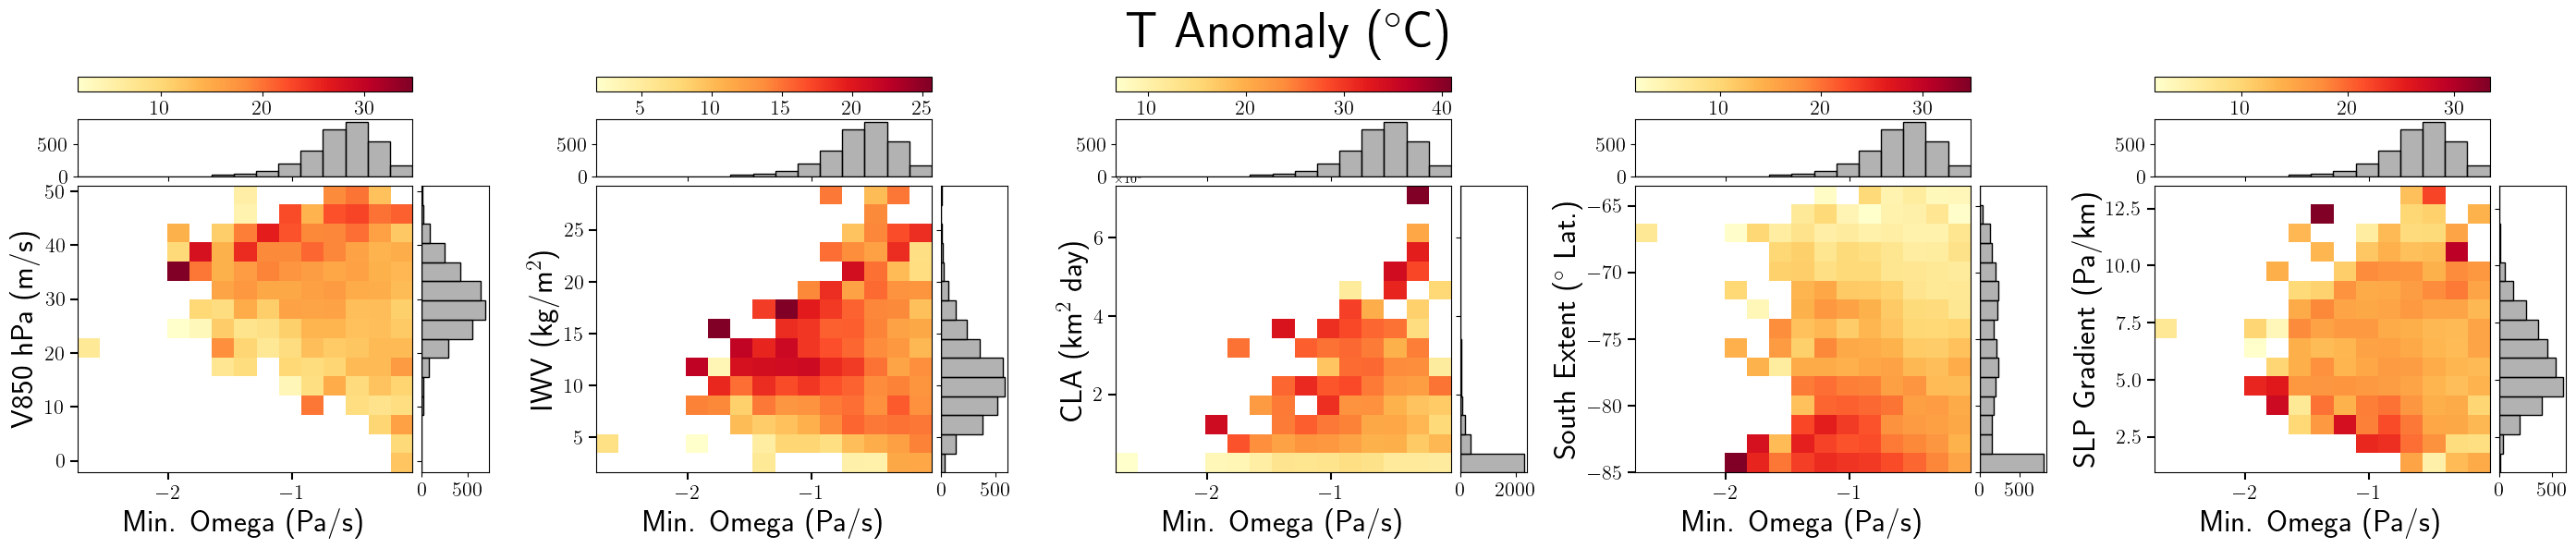

In [19]:
plot_feature_vs_others(
    target_col='avg_landfalling_minomega', 
    z_col='max_T2M_anomaly_ais', 
    catalog=subcat)

Some noteworthy findings:
+ Seems like just storms with high IWV have higher snowfall, regardless of wind speed.
+ Higher IWV and higher CLA have more cumulative snowfall, though it seems like CLA is more important.
+ Storms with more IWV and travel further south have higher cumulative snowfall.
+ Storms with higher IWV and a variety of SLPs can have high cumulative snowfall. However, it does seem like higher SLP gradient ARs can have more cumulative snowfall with moderate amounts of IWV.
+ Seems like there's a tradeoff between IWV and Omega. Moderate amounts of IWV and high omega produce similar amounts of snow as higher IWV and moderate Omega.

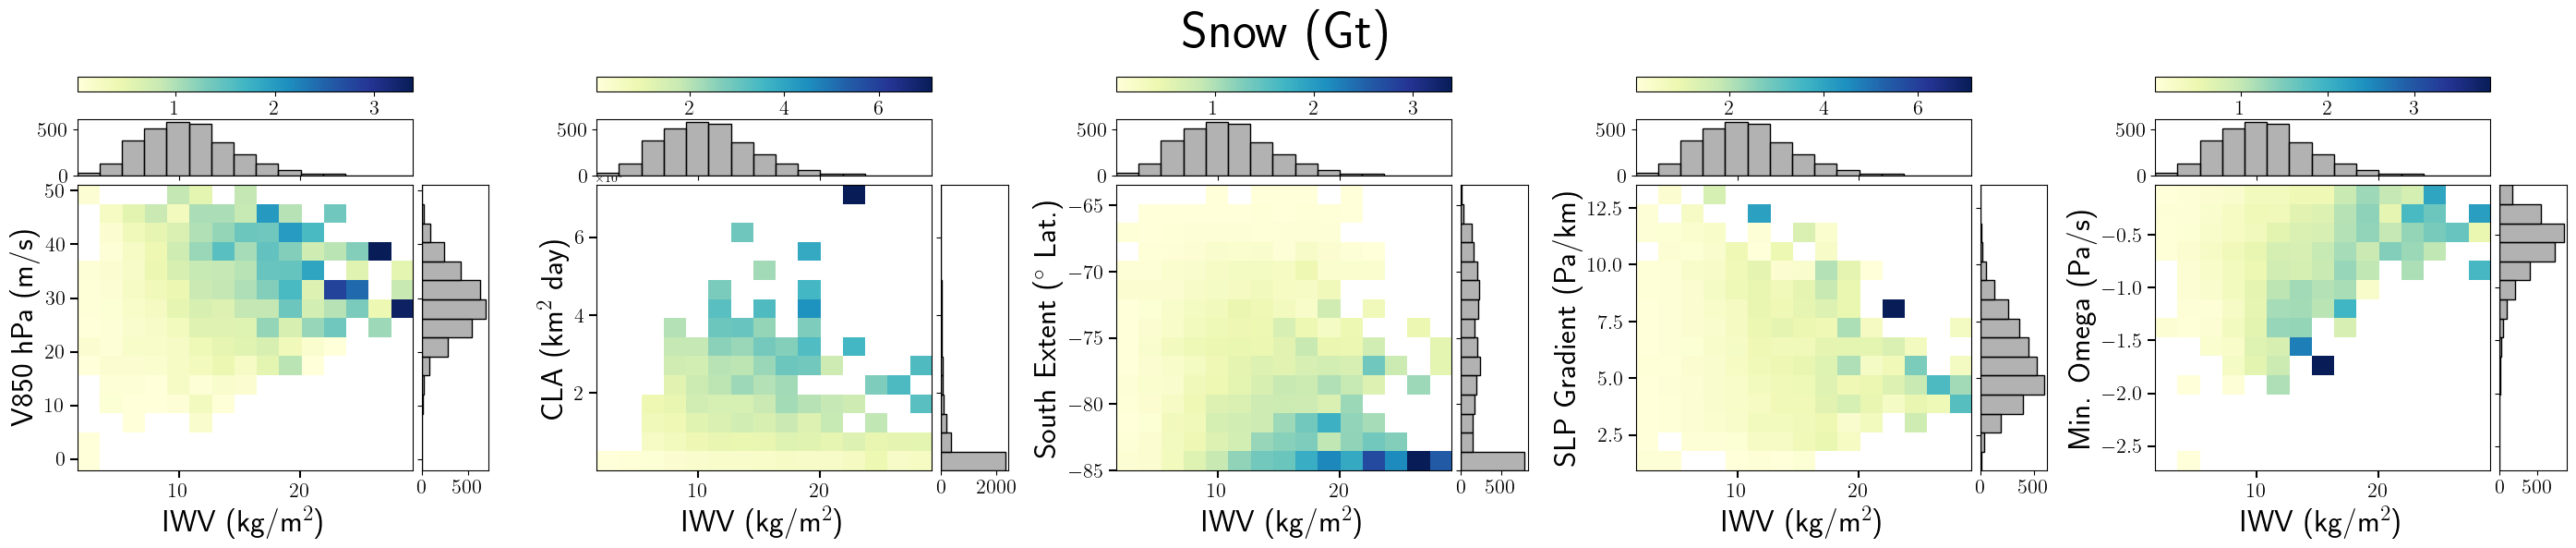

In [20]:
plot_feature_vs_others(
    target_col='max_IWV_ais', 
    z_col='cumulative_snowfall_ais', 
    catalog=subcat)

Some noteworthy findings:
+ Higher CLA across wind-speeds lead to higher snowfall.
+ Storms that travel further south and have higher wind speeds have more snowfall.
+ No discernible patterns. Seems that increasing SLP gradient if anything leads to less cumulative snowfall.
+ Winder storms with greater omega produce more snowfall, though it seems that the association with windiness is stronger.

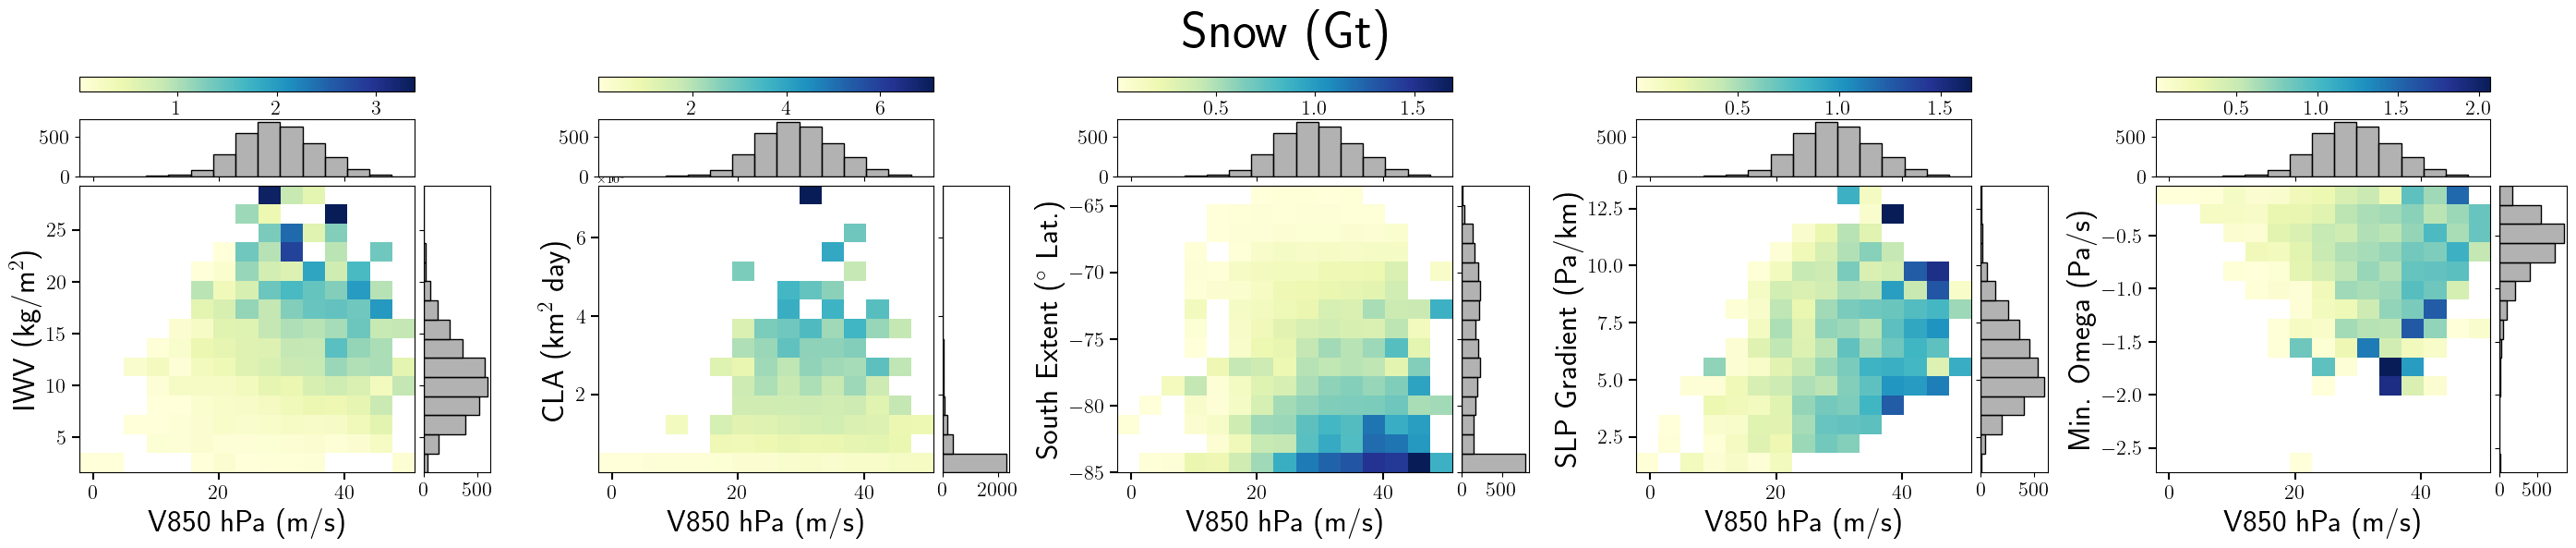

In [21]:
plot_feature_vs_others(
    target_col='max_landfalling_v850hPa', 
    z_col='cumulative_snowfall_ais', 
    catalog=subcat)

Some noteworthy findings:
+ ARs that travel further south and spend longer on the ice sheet produce more snowfall. There's not many storms that don't travel very far south and spend a long time on the ice sheet. Definitely seems like cumulative landfalling area is a bigger driver, as looking at fixed CLA there is no change in snowfall amounts across the southern extent values.
+ CLA is more important than SLP gradient.
+ Generally seems like there is some association between omega and snowfall for storms with smaller CLAs up to larger CLAs, but the association is more stark for fixed CLA. Generally seems like higher CLA and higher omega leads to more snowfall, though omega can be quite low and CLA can be high to produce massive amounts of snowfall.

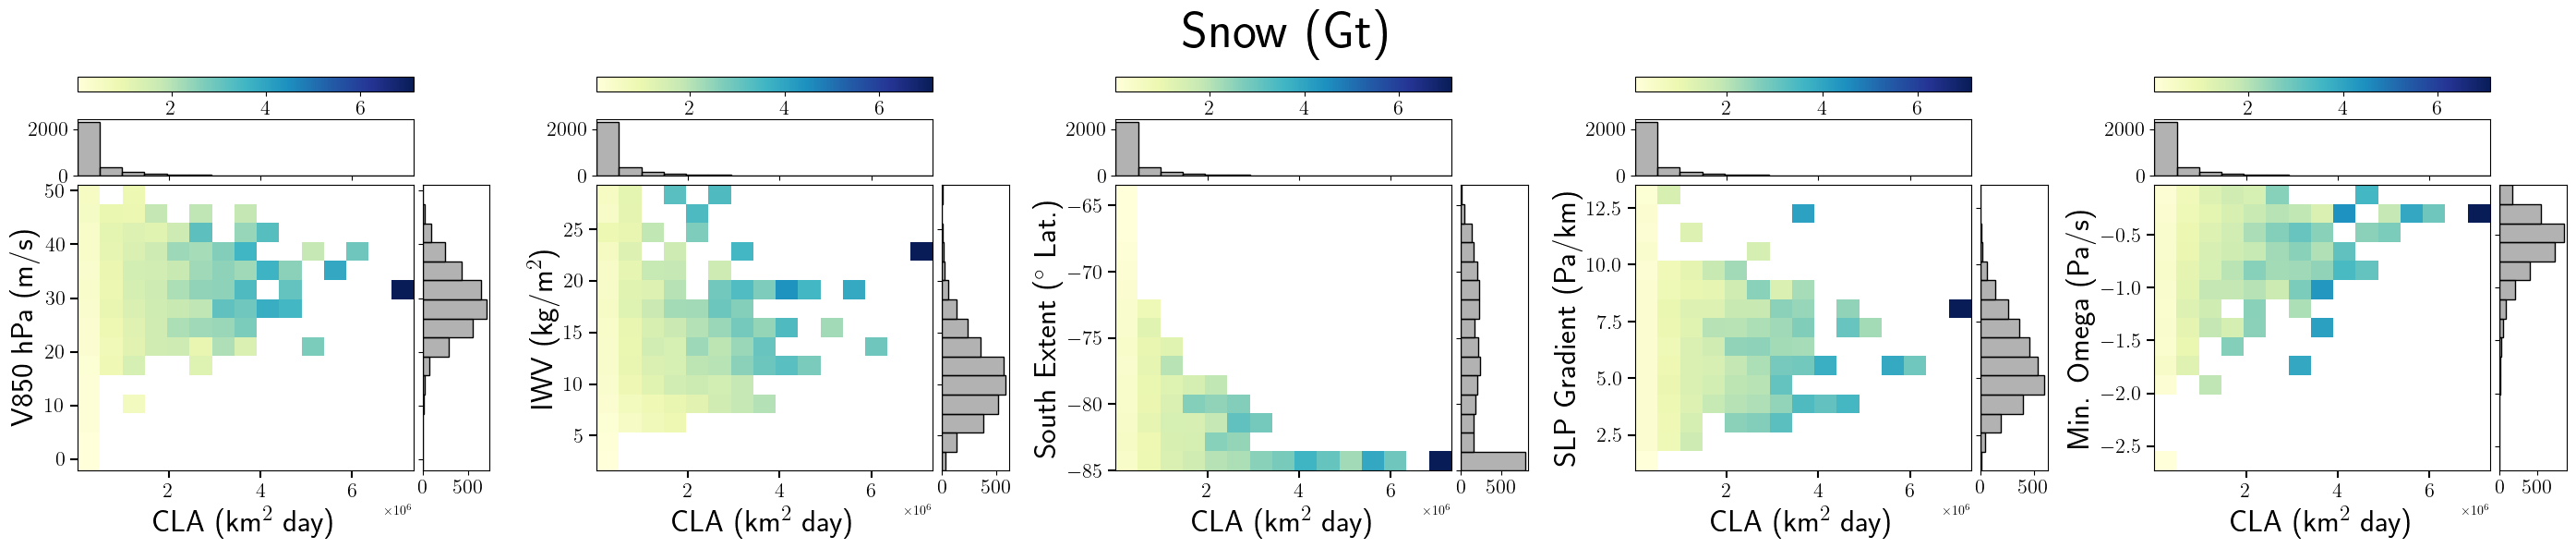

In [22]:
plot_feature_vs_others(
    target_col='cumulative_landfalling_area', 
    z_col='cumulative_snowfall_ais', 
    catalog=subcat)

Some noteworthy findings:
+ Mostly a matter of southern extent, but it does seem like storms with higher SLP also have higher cumulative snowfall amounts.
+ ARs that travel further south and have more lifting tend to have more cumulative snowfall. If you don't reach the south pole, having higher omega seems to help.

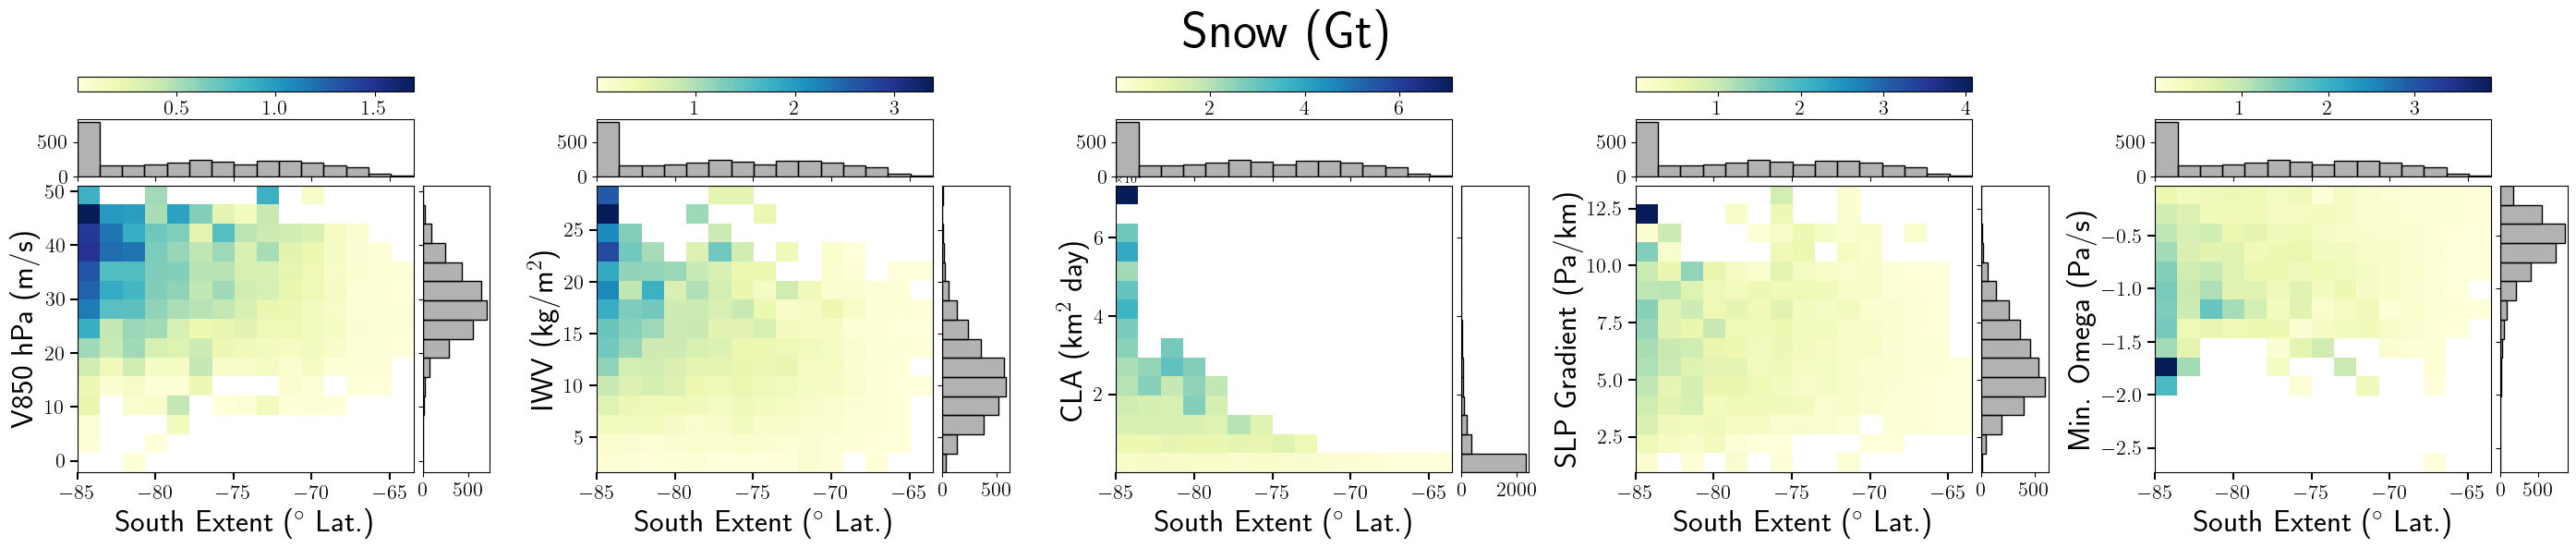

In [23]:
plot_feature_vs_others(
    target_col='max_south_extent', 
    z_col='cumulative_snowfall_ais', 
    catalog=subcat)

Let's further examine each row more closely.

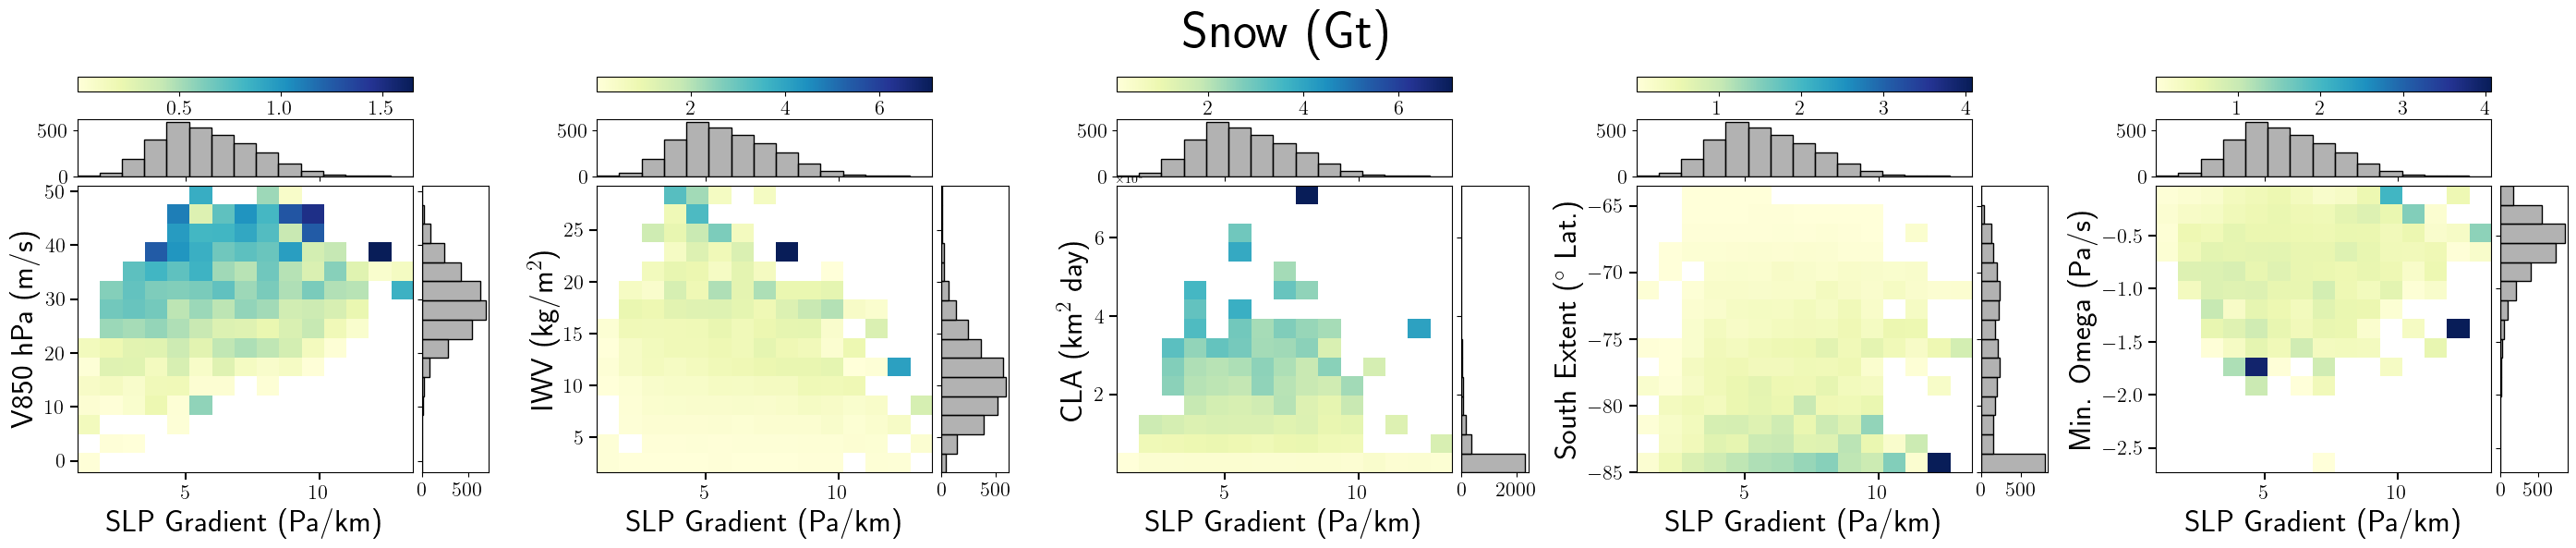

In [24]:
plot_feature_vs_others(
    target_col='max_ocean_SLP_gradient', 
    z_col='cumulative_snowfall_ais', 
    catalog=subcat)

Some noteworthy findings:
+ No discernible patterns between SLP gradient and lifting.

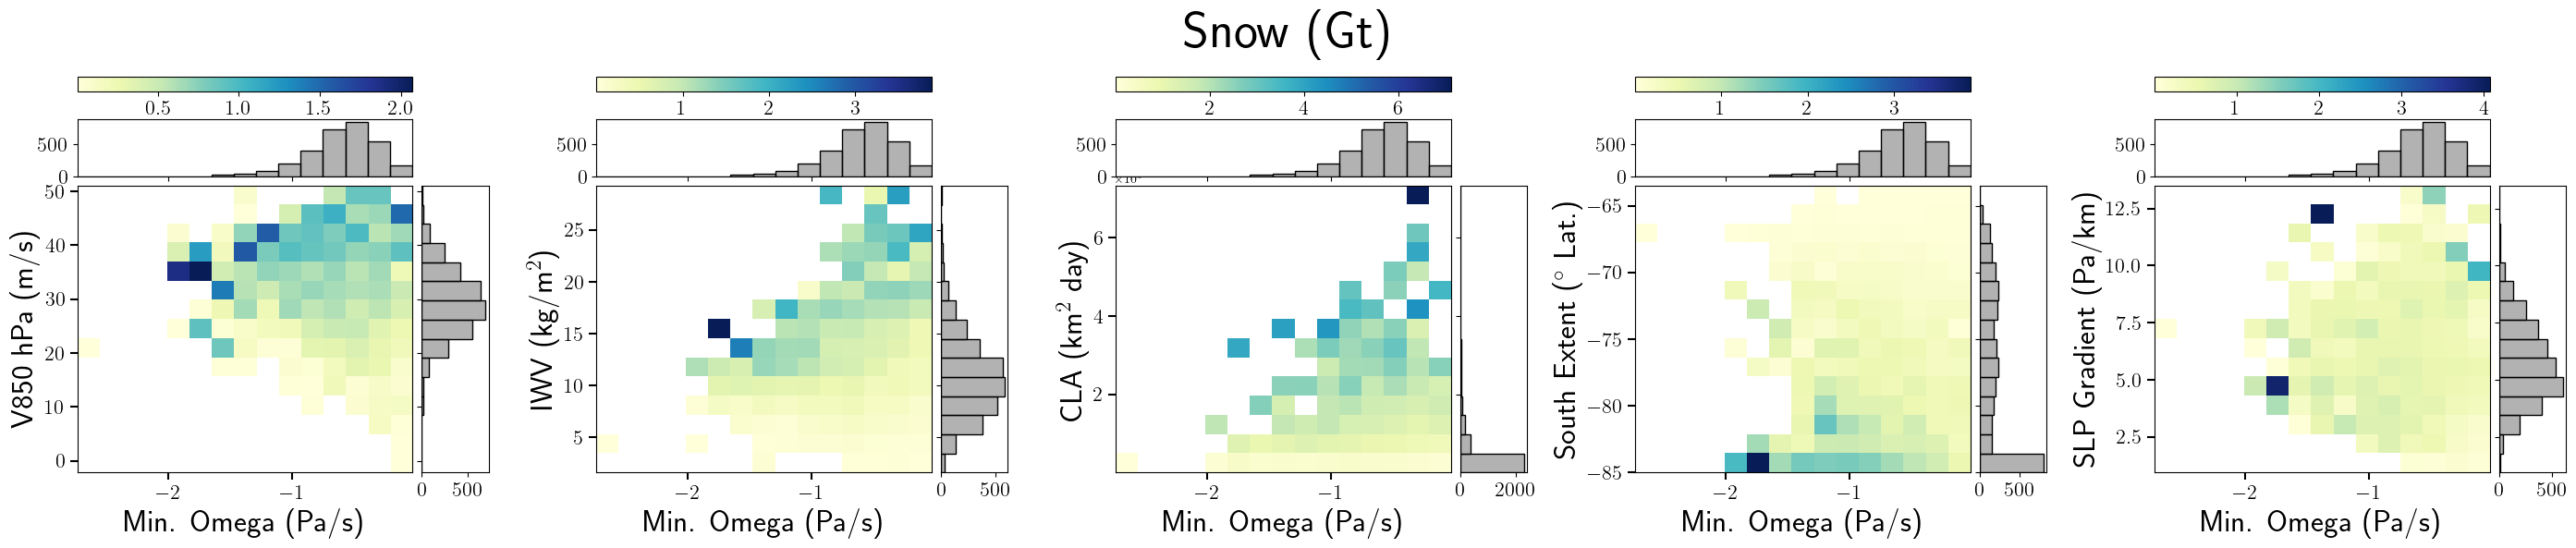

In [25]:
plot_feature_vs_others(
    target_col='avg_landfalling_minomega', 
    z_col='cumulative_snowfall_ais', 
    catalog=subcat)

This was a lot of plots! We are going to take a few of the most interesting associations for the main paper.

For temperature, we'll pick the following pairs of characteristics:
+ IWV and Wind
+ Southern extent and Wind
+ Southern extent and omega
+ Wind and omega

For snowfall, we'll pick the following pairs of characteristics:
+ IWV and Wind
+ IWV and omega
+ IWV and southern extent
+ Southern extent and wind

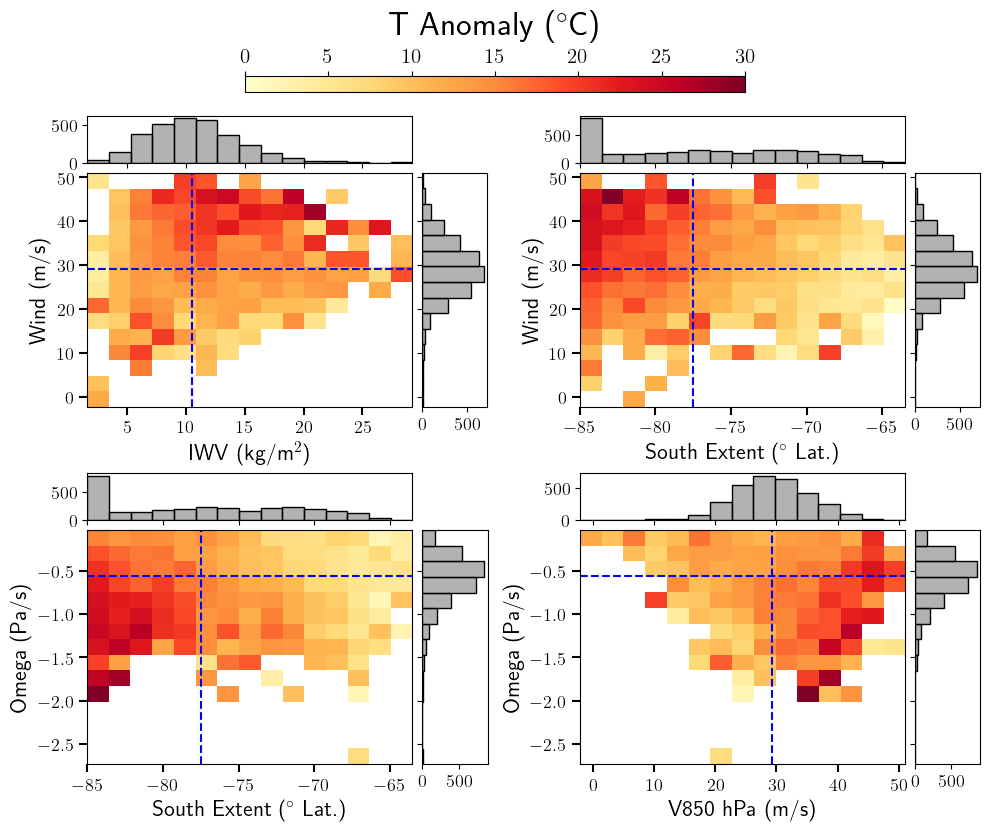

In [28]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

mappable = add_joint_plot(
    axs[0,0],
    subcat.max_IWV_ais.to_numpy().astype(float),
    subcat.max_landfalling_v850hPa.to_numpy().astype(float), 
    subcat.max_T2M_anomaly_ais.to_numpy().astype(float),
    cmap='YlOrRd',
    title='T Anomaly ($^{\\circ}$C)',
    ylabel='Wind (m/s)',
    xlabel='IWV (kg/m$^{2}$)',
    show_cbar=False,
    vmin=0,
    vmax=30,
    tick_size=13,
    label_size=16
)

add_joint_plot(
    axs[0,1],
    subcat.max_south_extent.to_numpy().astype(float),
    subcat.max_landfalling_v850hPa.to_numpy().astype(float), 
    subcat.max_T2M_anomaly_ais.to_numpy().astype(float),
    cmap='YlOrRd',
    title='T Anomaly ($^{\\circ}$C)',
    ylabel='Wind (m/s)',
    xlabel='South Extent ($^{\\circ}$ Lat.)',
    show_cbar=False,
    vmin=0,
    vmax=30,
    tick_size=13,
    label_size=16
)

add_joint_plot(
    axs[1,0],
    subcat.max_south_extent.to_numpy().astype(float),
    subcat.avg_landfalling_minomega.to_numpy().astype(float), 
    subcat.max_T2M_anomaly_ais.to_numpy().astype(float),
    cmap='YlOrRd',
    title='T Anomaly ($^{\\circ}$C)',
    ylabel='Omega (Pa/s)',
    xlabel='South Extent ($^{\\circ}$ Lat.)',
    show_cbar=False,
    vmin=0,
    vmax=30,
    tick_size=13,
    label_size=16
)

add_joint_plot(
    axs[1,1],
    subcat.max_landfalling_v850hPa.to_numpy().astype(float),
    subcat.avg_landfalling_minomega.to_numpy().astype(float), 
    subcat.max_T2M_anomaly_ais.to_numpy().astype(float),
    cmap='YlOrRd',
    title='T Anomaly ($^{\\circ}$C)',
    ylabel='Omega (Pa/s)',
    xlabel='V850 hPa (m/s)',
    show_cbar=False,
    vmin=0,
    vmax=30,
    tick_size=13,
    label_size=16
)


axs[0,0].axhline(y=subcat.max_landfalling_v850hPa.median(), color='b', linestyle='--')
axs[0,0].axvline(x=subcat.max_IWV_ais.median(), color='b', linestyle='--')
axs[0,1].axhline(y=subcat.max_landfalling_v850hPa.median(), color='b', linestyle='--')
axs[0,1].axvline(x=subcat.max_south_extent.median(), color='b', linestyle='--')
axs[1,0].axhline(y=subcat.avg_landfalling_minomega.median(), color='b', linestyle='--')
axs[1,0].axvline(x=subcat.max_south_extent.median(), color='b', linestyle='--')
axs[1,1].axhline(y=subcat.avg_landfalling_minomega.median(), color='b', linestyle='--')
axs[1,1].axvline(x=subcat.max_landfalling_v850hPa.median(), color='b', linestyle='--')


plt.tight_layout()
plt.subplots_adjust(top=0.9)
cbar_ax = fig.add_axes([0.25, 0.93, 0.5, 0.02])
cbar = fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
cbar.set_label('T Anomaly ($^{\\circ}$C)', fontsize=24, labelpad=10)
cbar.ax.tick_params(labelsize=15)

# Move the ticks to the top of the colorbar for a cleaner look (optional)
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')
plt.savefig('../outputs/plots/bivariate_associations_temp.png', dpi=300, bbox_inches='tight')

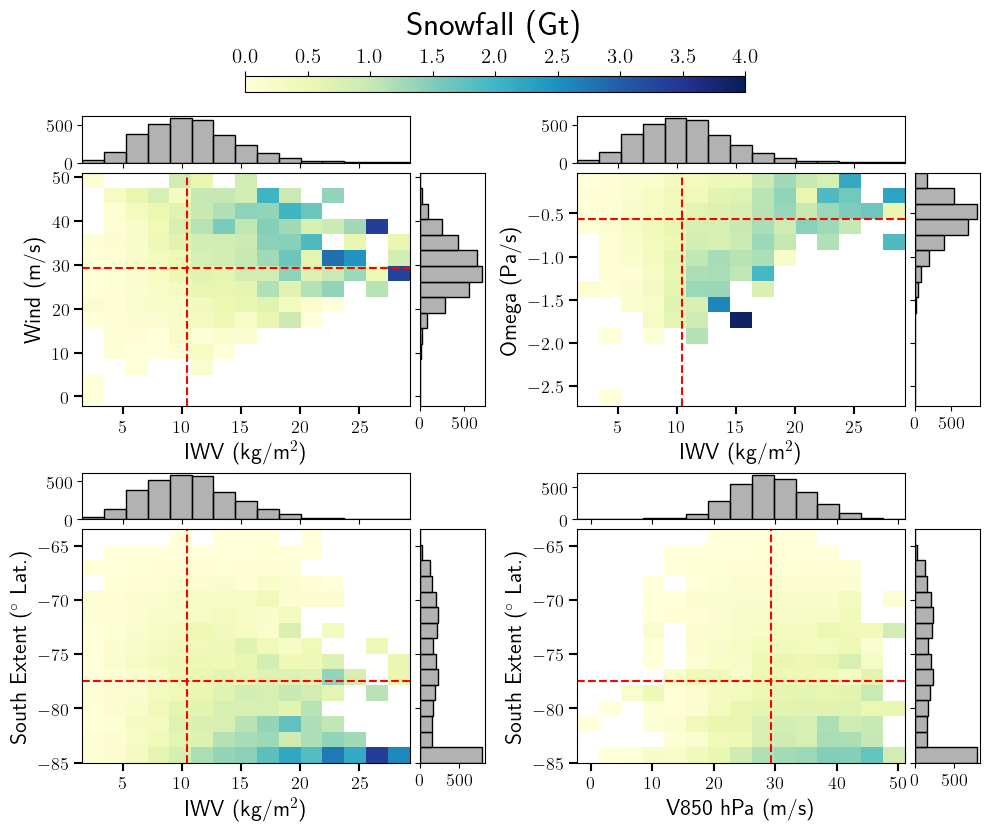

In [29]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

mappable = add_joint_plot(
    axs[0,0],
    subcat.max_IWV_ais.to_numpy().astype(float),
    subcat.max_landfalling_v850hPa.to_numpy().astype(float), 
    subcat.cumulative_snowfall_ais.to_numpy().astype(float),
    cmap='YlGnBu',
    title='Snow (Gt)',
    ylabel='Wind (m/s)',
    xlabel='IWV (kg/m$^{2}$)',
    show_cbar=False,
    vmin=0,
    vmax=4,
    tick_size=13,
    label_size=16
)

add_joint_plot(
    axs[0,1],
    subcat.max_IWV_ais.to_numpy().astype(float),
    subcat.avg_landfalling_minomega.to_numpy().astype(float), 
    subcat.cumulative_snowfall_ais.to_numpy().astype(float),
    cmap='YlGnBu',
    title='Snow (Gt)',
    ylabel='Omega (Pa/s)',
    xlabel='IWV (kg/m$^{2}$)',
    show_cbar=False,
    vmin=0,
    vmax=4,
    tick_size=13,
    label_size=16
)

add_joint_plot(
    axs[1,0],
    subcat.max_IWV_ais.to_numpy().astype(float),
    subcat.max_south_extent.to_numpy().astype(float), 
    subcat.cumulative_snowfall_ais.to_numpy().astype(float),
    cmap='YlGnBu',
    title='Snow (Gt)',
    ylabel='South Extent ($^{\\circ}$ Lat.)',
    xlabel='IWV (kg/m$^{2}$)',
    show_cbar=False,
    vmin=0,
    vmax=4,
    tick_size=13,
    label_size=16
)

add_joint_plot(
    axs[1,1],
    subcat.max_landfalling_v850hPa.to_numpy().astype(float),
    subcat.max_south_extent.to_numpy().astype(float), 
    subcat.cumulative_snowfall_ais.to_numpy().astype(float),
    cmap='YlGnBu',
    title='Snow (Gt)',
    ylabel='South Extent ($^{\\circ}$ Lat.)',
    xlabel='V850 hPa (m/s)',
    show_cbar=False,
    vmin=0,
    vmax=4,
    tick_size=13,
    label_size=16
)


axs[0,0].axhline(y=subcat.max_landfalling_v850hPa.median(), color='r', linestyle='--')
axs[0,0].axvline(x=subcat.max_IWV_ais.median(), color='r', linestyle='--')
axs[0,1].axhline(y=subcat.avg_landfalling_minomega.median(), color='r', linestyle='--')
axs[0,1].axvline(x=subcat.max_IWV_ais.median(), color='r', linestyle='--')
axs[1,0].axhline(y=subcat.max_south_extent.median(), color='r', linestyle='--')
axs[1,0].axvline(x=subcat.max_IWV_ais.median(), color='r', linestyle='--')
axs[1,1].axhline(y=subcat.max_south_extent.median(), color='r', linestyle='--')
axs[1,1].axvline(x=subcat.max_landfalling_v850hPa.median(), color='r', linestyle='--')


plt.tight_layout()
plt.subplots_adjust(top=0.9)
cbar_ax = fig.add_axes([0.25, 0.93, 0.5, 0.02])
cbar = fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Snowfall (Gt)', fontsize=24, labelpad=10)
cbar.ax.tick_params(labelsize=15)

# Move the ticks to the top of the colorbar for a cleaner look (optional)
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')
plt.savefig('../outputs/plots/bivariate_associations_snow.png', dpi=300, bbox_inches='tight')